In [179]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import random
import scipy
from scipy import stats


#Descriptive analysis

In [2]:
random.seed(0)

data = pd.DataFrame({
    'x':np.random.randint(1,100, size=(100)),
    'y':np.random.randint(1,100, size=(100)),
    'z':np.random.randint(0,2, size=(100))
})


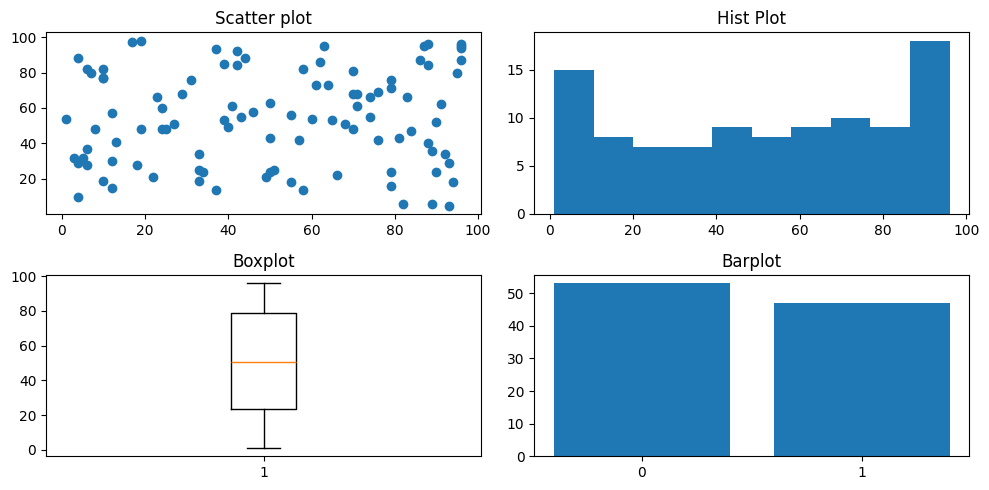

In [3]:
plt.figure(figsize=(10,5))

plt.subplot(2,2,1)
plt.scatter(data['x'], data['y'])
plt.title('Scatter plot')

plt.subplot(2,2,2)
plt.hist(data['x'])
plt.title('Hist Plot')

plt.subplot(2,2,3)
plt.boxplot(data['x'])
plt.title('Boxplot')

plt.subplot(2,2,4)
plt.bar(x=['0','1'], height=data['z'].value_counts())
plt.title('Barplot')

plt.tight_layout()
plt.show()


In [4]:
data['z'].value_counts()

,count
z,
0,53
1,47


In [5]:
data.drop('z', axis=1).describe().round(4)

,x,y
count,100.0000,100.0000
mean,50.8100,53.8300
std,30.5107,26.5121
min,1.0000,5.0000
25%,23.7500,29.7500
50%,50.5000,53.5000
75%,79.0000,77.0000
max,96.0000,98.0000


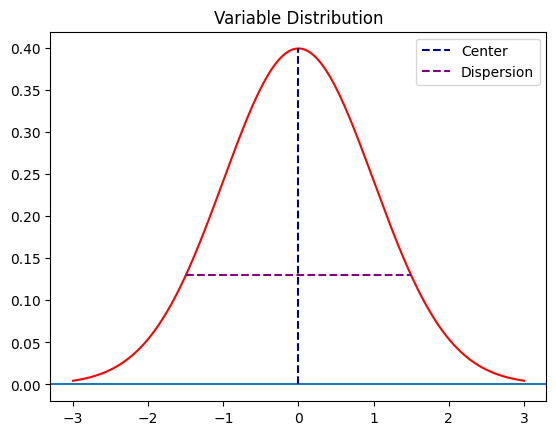

In [6]:
x = np.linspace(-3, 3, 1000)
y = scipy.stats.norm.pdf(x)

plt.plot(x, y, color='red')
plt.axhline()
plt.vlines(x=0, ymin=0, ymax=scipy.stats.norm.pdf(0),
           linestyles='dashed', label='Center', color='darkblue')
plt.hlines(y=scipy.stats.norm.pdf(-1.5), xmin=-1.5, xmax=1.5,
           linestyles='dashed', label='Dispersion', color='purple')
plt.title('Variable Distribution')

plt.legend()

plt.show()

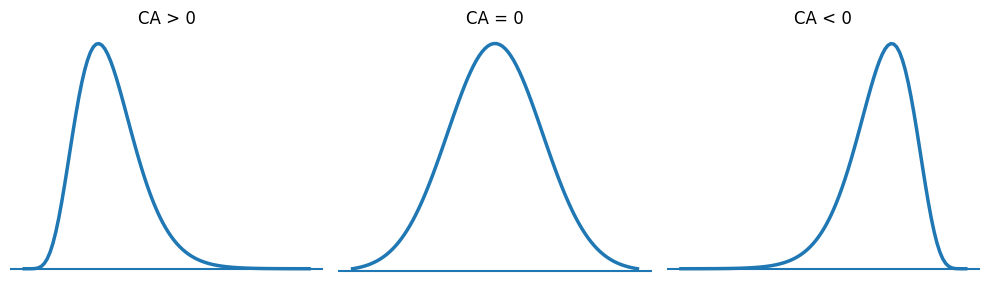

In [7]:
nvalues = 100
df = 15

plt.figure(figsize=(10, 3))

xnorm = np.linspace(-3, 3, nvalues)
xchi2 = np.linspace(0, 50, nvalues)
y1 = scipy.stats.norm.pdf(xnorm)
y2 = scipy.stats.chi2.pdf(xchi2, df=df)

plt.subplot(1,3,1)
plt.plot(xchi2, y2,  linewidth=2.5)
plt.axis('off')
# plt.vlines(np.mean(xchi2), ymin=0, ymax=scipy.stats.chi2.pdf(np.mean(xchi2), df=df),
#            linestyles='dashed', color='red', label='Mean')
# plt.vlines(np.median(xchi2)-5, ymin=0, ymax=scipy.stats.chi2.pdf(np.median(xchi2)-5, df=df),
#            linestyles='dashed', color='blue', label='Median')
plt.axhline(0)
# plt.legend(fontsize=25)
plt.title('CA > 0')

plt.subplot(1,3,2)
plt.plot(xnorm, y1, linewidth=2.5)
plt.axis('off')
# plt.vlines(0, ymin=0, ymax=scipy.stats.norm.pdf(np.mean(xnorm)),
#            linestyles='dashed', color='red', label='Mean')
# plt.vlines(0, ymin=0, ymax=scipy.stats.norm.pdf(np.median(xnorm)),
#            linestyles='dashed', color='blue', label='Median')
plt.axhline(0)
plt.title('CA = 0')

plt.subplot(1,3,3)
plt.plot(-xchi2, y2, linewidth=2.5)
plt.axis('off')
plt.axhline(0)
# plt.vlines(-np.mean(xchi2), ymin=0, ymax=scipy.stats.chi2.pdf(np.mean(xchi2), df=df),
#            linestyles='dashed', color='red', label='Mean')
# plt.vlines(-np.median(xchi2)+5, ymin=0, ymax=scipy.stats.chi2.pdf(np.median(xchi2)-5, df=df),
#            linestyles='dashed', color='blue', label='Median')
plt.title('CA < 0')

plt.tight_layout()

plt.show()

[]

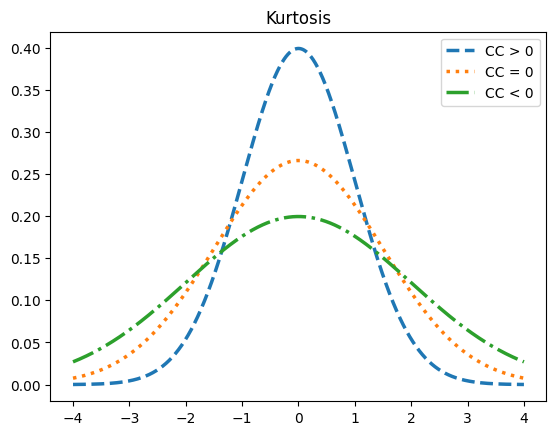

In [8]:
r = [-4, 4]
nvalues = 1000
df = [10000, 10, 5]

x = np.linspace(r[0], r[1], nvalues)
y1 = scipy.stats.norm.pdf(x, loc=0, scale=1)
y2 = scipy.stats.norm.pdf(x, loc=0, scale=1.5)
y3 = scipy.stats.norm.pdf(x, loc=0, scale=2)

plt.subplot(1,1,1)
plt.plot(x, y1, label='CC > 0', linestyle='--', linewidth=2.5)
plt.subplot(1,1,1)
plt.plot(x, y2, label='CC = 0', linestyle=':', linewidth=2.5)
plt.subplot(1,1,1)
plt.plot(x, y3, label='CC < 0', linestyle='-.', linewidth=2.5)

plt.title('Kurtosis')

plt.legend(fontsize=10)

plt.plot()

In [9]:
# Tablas de frecuencia
random.seed(123)

state = np.array(random.choices(['sick', 'not sick'], k=100))
exposure = np.array(random.choices(['exposed', 'not exposed'], k=100))

In [10]:
tabla = pd.DataFrame(pd.Series(state).value_counts())
tabla['acum_count'] = np.cumsum(tabla['count'])
tabla['percent'] = tabla['count'] / np.sum(tabla['count']) *100
tabla['acum_percent'] = np.cumsum(tabla['percent'])


tabla

,count,acum_count,percent,acum_percent
sick,61,61,61.0,61.0
not sick,39,100,39.0,100.0


In [11]:
pd.crosstab(state, exposure)

col_0,exposed,not exposed
row_0,,
not sick,16,23
sick,30,31


In [12]:
random.seed(123)
pd.Series(np.array(random.choices(range(20,71), k=50))).describe()

,0
count,50.000000
mean,42.320000
std,14.705878
min,20.000000
25%,29.250000
50%,41.000000
75%,54.000000
max,66.000000


#Data Visualization

##Cuantitative variables


In [13]:
from sklearn import datasets

Info for features of the dataset is presented here:

- radius (mean of distances from center to points on the perimeter)

- texture (standard deviation of gray-scale values)

- perimeter

- area

- smoothness (local variation in radius lengths)

- compactness (perimeter^2 / area - 1.0)

- concavity (severity of concave portions of the contour)

- concave points (number of concave portions of the contour)

- symmetry

- fractal dimension (“coastline approximation” - 1)  
The mean, standard error, and “worst” or largest (mean of the three worst/largest values) of these features were computed for each image, resulting in 30 features. For instance, field 0 is Mean Radius, field 10 is Radius SE, field 20 is Worst Radius.

- class:  
WDBC-Malignant (1)  
WDBC-Benign (0)

In [14]:
cancer = datasets.load_breast_cancer(as_frame=True)
cancer = cancer.frame
cancer.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [15]:
cancer['target'] = cancer['target'].replace({1:'WDBS-Benign', 0:'WDBC-Malignant'})

In [16]:
cancer['target'].value_counts().values

array([357, 212])

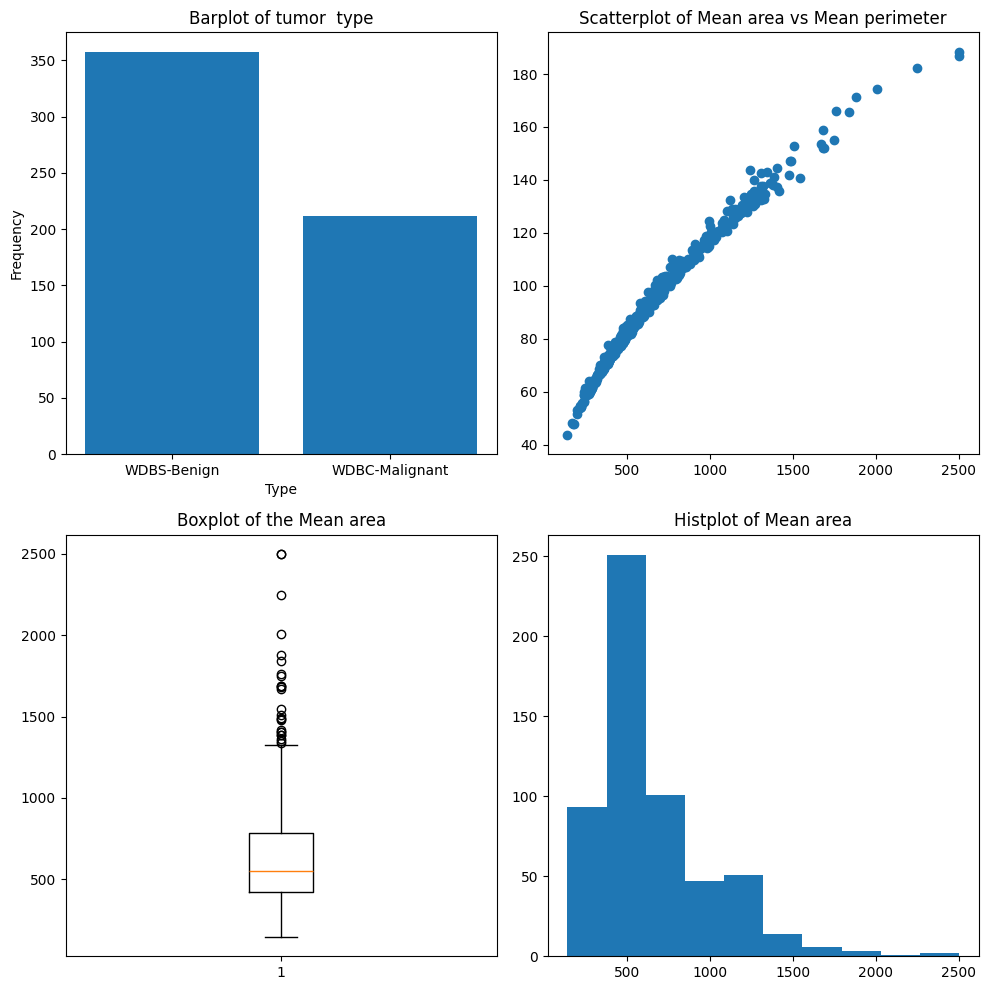

In [17]:
# Combined graph
plt.figure(figsize=(10,10))

plt.subplot(2,2,1)
plt.bar(x=cancer['target'].value_counts().index,
        height=cancer['target'].value_counts().values)
plt.title('Barplot of tumor  type')
plt.xlabel('Type')
plt.ylabel('Frequency')

plt.subplot(2,2,2)
plt.scatter(cancer['mean area'], cancer['mean perimeter'])
plt.title('Scatterplot of Mean area vs Mean perimeter')

plt.subplot(2,2,3)
plt.boxplot(cancer['mean area'])
plt.title('Boxplot of the Mean area')

plt.subplot(2,2,4)
plt.hist(cancer['mean area'])
plt.title('Histplot of Mean area')

plt.tight_layout()

plt.show()

In [18]:
sex = np.array(random.choices(['Men', 'Women'], k=cancer.shape[0]))

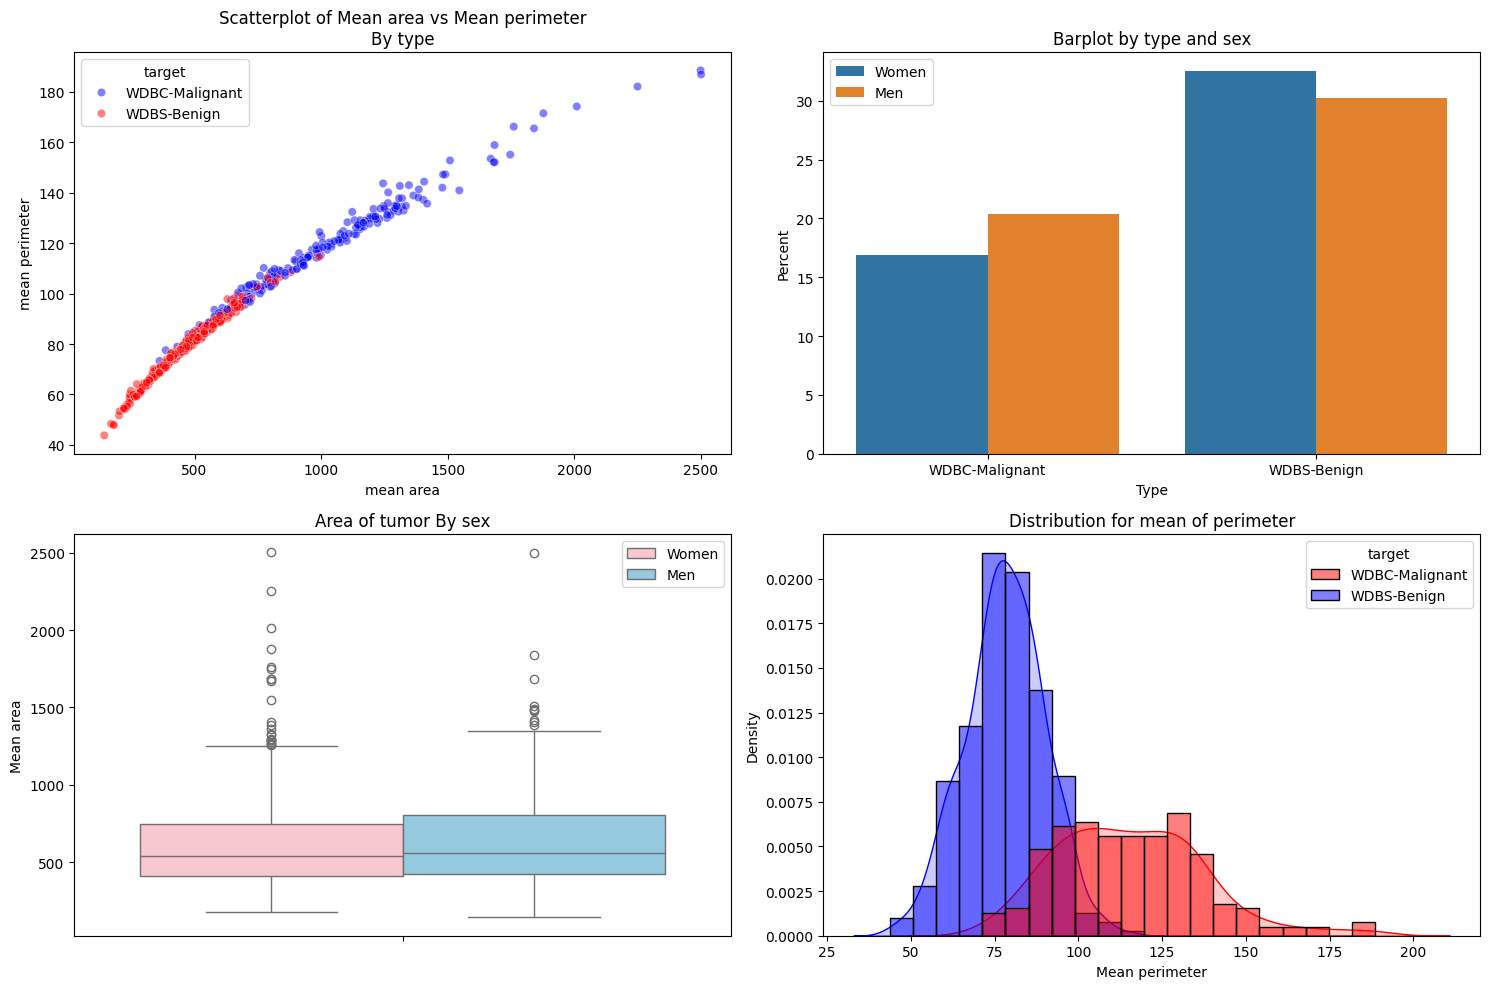

In [19]:
plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
sns.scatterplot(cancer, x='mean area', y='mean perimeter', hue='target',
                palette=['blue', 'red'], alpha=0.5)
plt.title('Scatterplot of Mean area vs Mean perimeter\nBy type')


plt.subplot(2,2,2)
sns.countplot(data=cancer, x='target', hue=sex, stat='percent')
plt.title('Barplot by type and sex')
plt.xlabel('Type')
plt.ylabel('Percent')

plt.subplot(2,2,3)
sns.boxplot(data=cancer, y='mean area', hue=sex, palette=['pink', 'skyblue'])
plt.title('Area of tumor By sex')
plt.ylabel('Mean area')

plt.subplot(2,2,4)
sns.kdeplot(data=cancer, x='mean perimeter', hue='target', palette=['red', 'blue'],
            fill=['red', 'blue'], alpha=0.2)
sns.histplot(data=cancer, x='mean perimeter', hue='target', palette=['red', 'blue'],
             fill=['red', 'blue'], alpha=0.5, stat='density')
plt.title('Distribution for mean of perimeter')
plt.xlabel('Mean perimeter')

plt.tight_layout()

plt.show()

In [20]:
!pip install -q geopandas geodatasets

In [21]:
import geopandas as gdp
import geodatasets

In [22]:
url_ecuador = 'https://data.humdata.org/dataset/e66dbc70-17fe-4230-b9d6-855d192fc05c/resource/6fa37b41-ad28-40a6-9641-3b4efd4dbe13/download/ecuador.geojson'
ecuador = gdp.read_file(url_ecuador)

In [23]:
ecuador[['DPA_DESPRO', 'geometry']]

,DPA_DESPRO,geometry
0,AZUAY,"MULTIPOLYGON (((-79.39303 -2.49798, -79.39052 ..."
1,AZUAY,"MULTIPOLYGON (((-79.02892 -3.17588, -79.02701 ..."
2,AZUAY,"MULTIPOLYGON (((-78.63193 -2.93822, -78.63687 ..."
3,AZUAY,"MULTIPOLYGON (((-78.93581 -3.28822, -78.93412 ..."
4,AZUAY,"MULTIPOLYGON (((-78.6419 -2.72233, -78.64778 -..."
...,...,...
219,SANTA ELENA,"MULTIPOLYGON (((-80.87062 -2.27018, -80.87315 ..."
220,SANTA ELENA,"MULTIPOLYGON (((-80.922 -2.21943, -80.92059 -2..."
221,ZONA NO DELIMITADA,"MULTIPOLYGON (((-78.92286 0.35833, -78.92784 0..."
222,ZONA NO DELIMITADA,"MULTIPOLYGON (((-79.45992 -0.50373, -79.45941 ..."


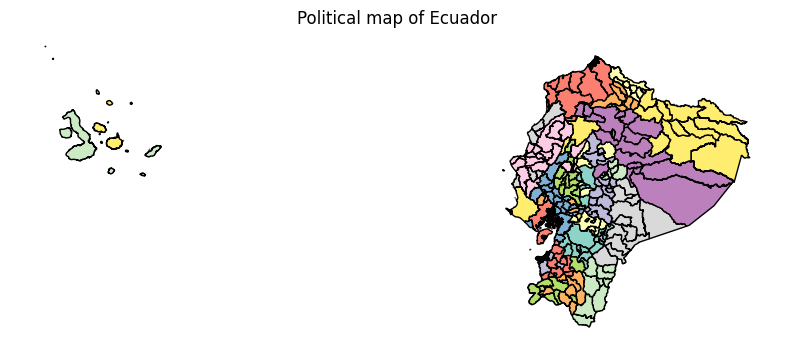

In [24]:
fig, ax = plt.subplots(figsize=(10,8))
ecuador.plot(ax=ax, edgecolor='black', cmap='Set3')

plt.title('Political map of Ecuador')

plt.axis('off')

plt.show()

[]

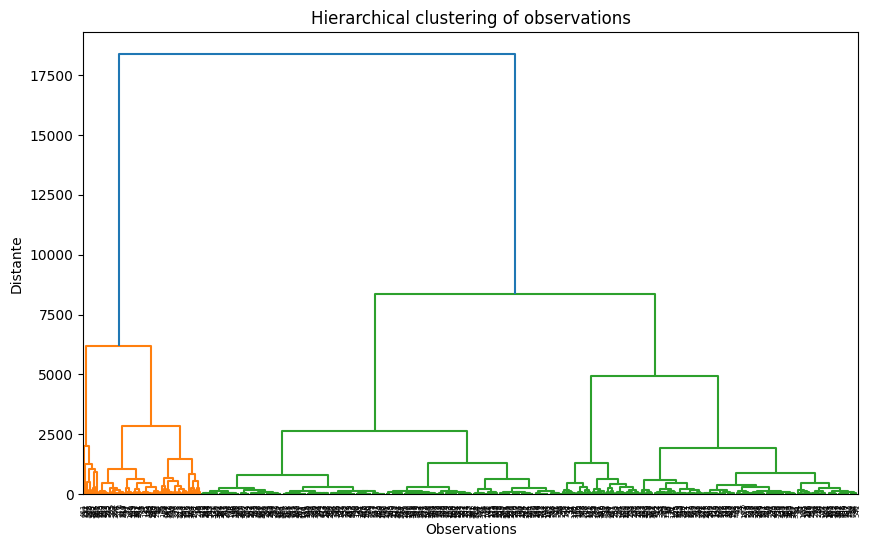

In [25]:
# Dendrogram
Z = scipy.cluster.hierarchy.linkage(cancer.drop('target', axis=1), method='ward')

plt.figure(figsize=(10,6))

scipy.cluster.hierarchy.dendrogram(Z)

plt.title('Hierarchical clustering of observations')
plt.ylabel('Distante')
plt.xlabel('Observations')

plt.plot()

Text(0.5, 1.0, 'Heatmap')

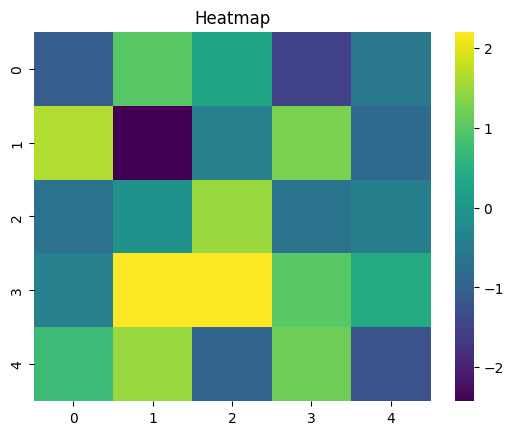

In [26]:
# Heatmap

np.random.seed(123)

sns.heatmap(np.random.randn(5,5), cmap='viridis')
plt.title('Heatmap')

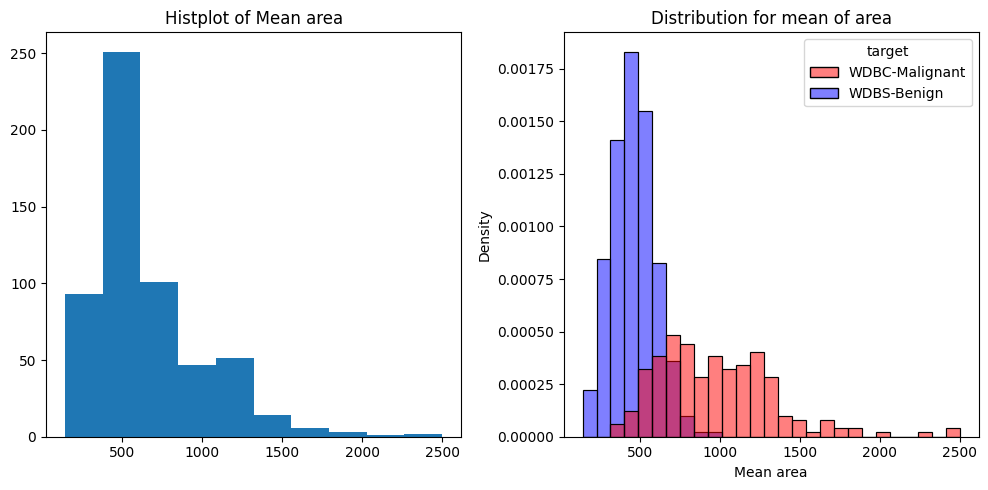

In [27]:
# Histplot

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.hist(cancer['mean area'])
plt.title('Histplot of Mean area')

plt.subplot(1,2,2)
# sns.kdeplot(data=cancer, x='mean perimeter', hue='target', palette=['red', 'blue'], fill=['red', 'blue'], alpha=0.2)
sns.histplot(data=cancer, x='mean area', hue='target', palette=['red', 'blue'], fill=['red', 'blue'], alpha=0.5, stat='density')
plt.title('Distribution for mean of area')
plt.xlabel('Mean area')

plt.tight_layout()

plt.show()


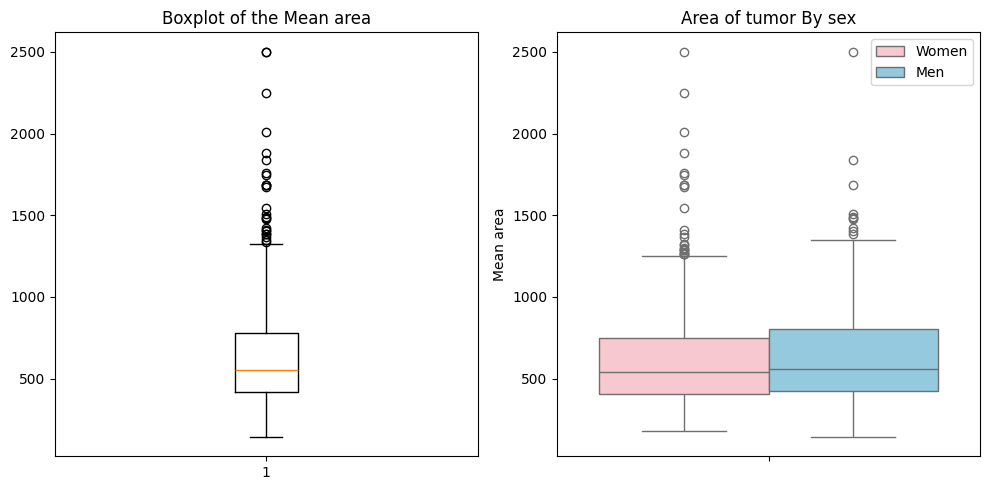

In [28]:
# Boxplot

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.boxplot(cancer['mean area'])
plt.title('Boxplot of the Mean area')

plt.subplot(1,2,2)
sns.boxplot(data=cancer, y='mean area', hue=sex, palette=['pink', 'skyblue'])
plt.title('Area of tumor By sex')
plt.ylabel('Mean area')

plt.tight_layout()

plt.show()

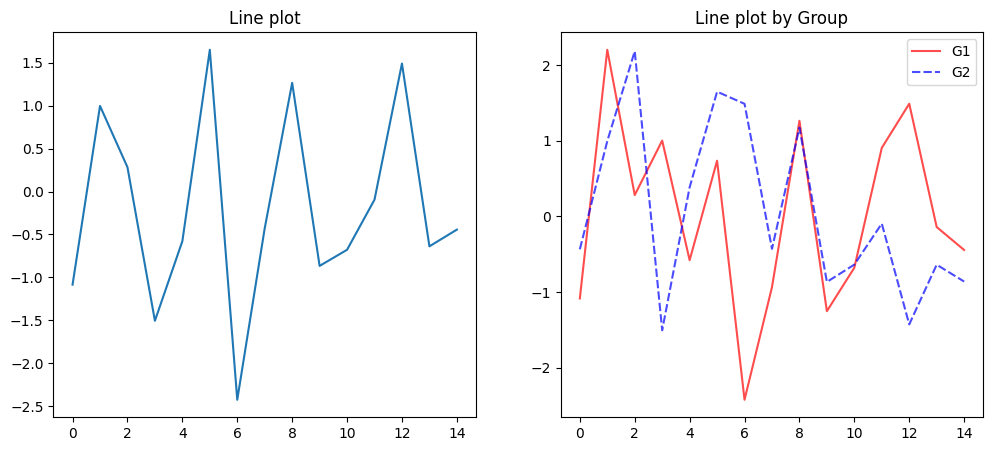

In [29]:
# Line plot

plt.figure(figsize=(12,5))

np.random.seed(123)
values1 = np.random.randn(15)
values2 = np.random.randn(15)

plt.subplot(1,2,1)
plt.plot(range(values1.shape[0]), values1)
plt.title('Line plot')

plt.subplot(1,2,2)
sns.lineplot(x = [i for i in range(values1.shape[0])] * 2, y=np.concat([values1, values2]),
             hue=['G1' if i%2==0 else 'G2' for i in range(np.concat([values1, values2]).shape[0])],
             palette=['red','blue'], alpha=0.7,
             style=['G1' if i%2==0 else 'G2' for i in range(np.concat([values1, values2]).shape[0])])
plt.title('Line plot by Group')


plt.show()

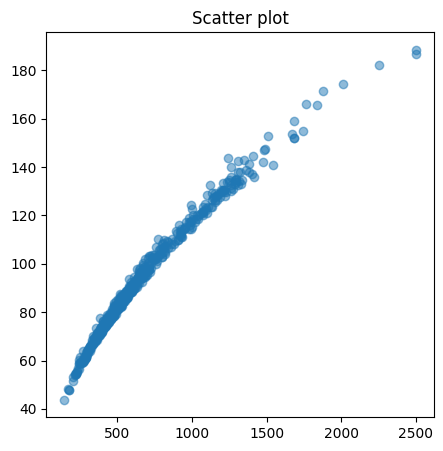

In [30]:
# Scatter plot

plt.figure(figsize=(5,5))

plt.scatter(cancer['mean area'], cancer['mean perimeter'], alpha=0.5)
plt.title('Scatter plot')

plt.show()

Text(0.5, 1.0, 'Heatmap')

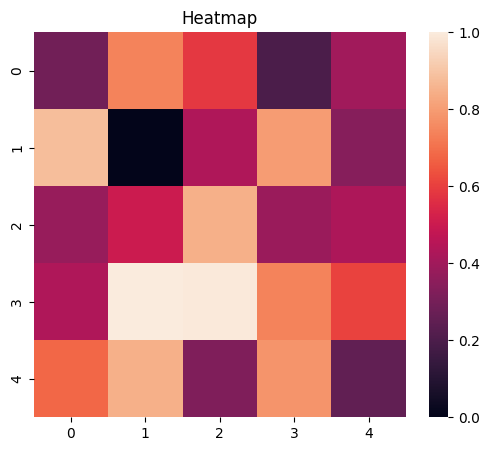

In [31]:
# Heatmap

np.random.seed(123)

matriz = np.random.randn(5,5)
matriz = (matriz - np.min(matriz)) / (np.max(matriz) - np.min(matriz))

plt.figure(figsize=(6, 5))
sns.heatmap(matriz)
plt.title('Heatmap')


<Figure size 600x500 with 0 Axes>

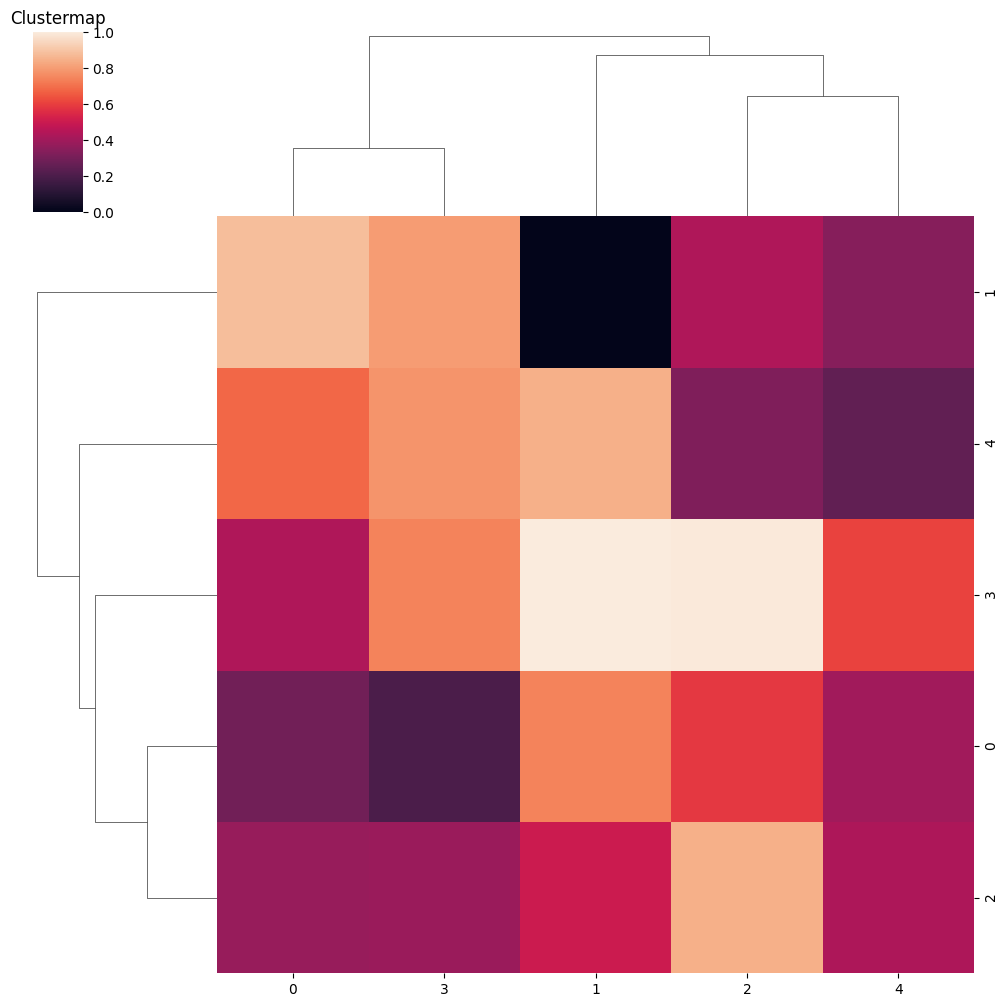

In [32]:
# Clustermap

plt.figure(figsize=(6, 5))
sns.clustermap(matriz)
plt.title('Clustermap')

plt.show()

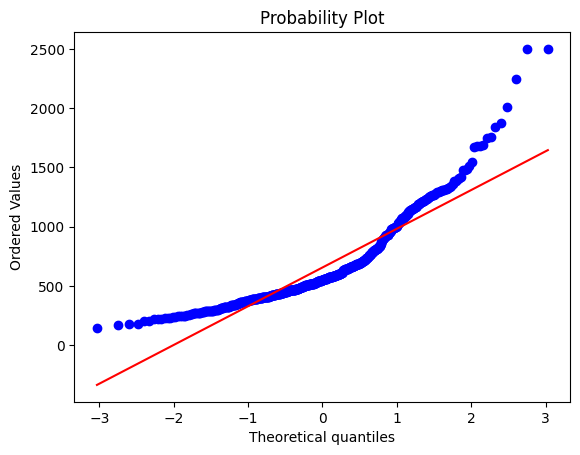

In [33]:
# Q-Q plot

import pylab

scipy.stats.probplot(cancer['mean area'], plot=pylab)
plt.show()


##Cualitative variables

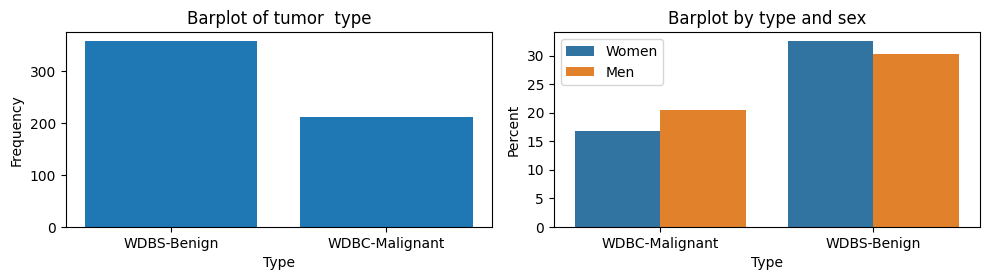

In [34]:
# Barplot

plt.figure(figsize=(10,5))

plt.subplot(2,2,1)
plt.bar(x=cancer['target'].value_counts().index,
        height=cancer['target'].value_counts().values)
plt.title('Barplot of tumor  type')
plt.xlabel('Type')
plt.ylabel('Frequency')

plt.subplot(2,2,2)
sns.countplot(data=cancer, x='target', hue=sex, stat='percent')
plt.title('Barplot by type and sex')
plt.xlabel('Type')
plt.ylabel('Percent')

plt.tight_layout()

plt.show()

<Figure size 1000x1000 with 0 Axes>

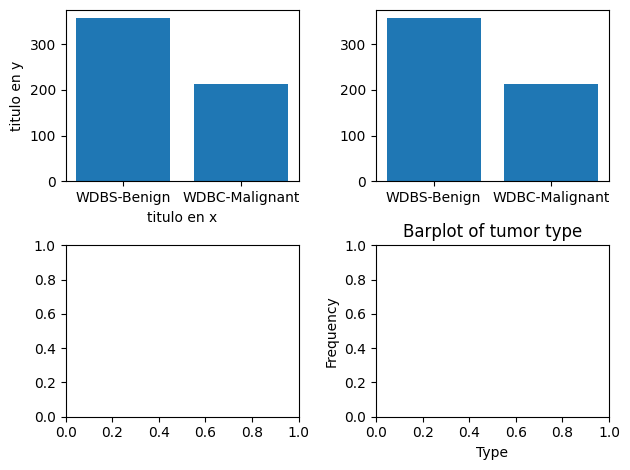

In [35]:
plt.figure(figsize=(10,10))

fig, ax = plt.subplots(2,2)

ax[0,0].bar(x=cancer['target'].value_counts().index,
       height=cancer['target'].value_counts().values)
ax[0,0].set_ylabel('titulo en y')
ax[0,0].set_xlabel('titulo en x')

ax[0,1].bar(x=cancer['target'].value_counts().index,
       height=cancer['target'].value_counts().values)

# ax.title()

plt.title('Barplot of tumor type')
plt.xlabel('Type')
plt.ylabel('Frequency')

plt.tight_layout()

plt.show()

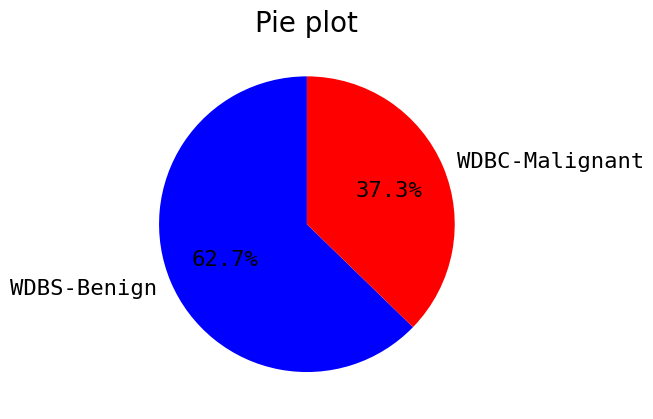

In [36]:
plt.pie(x=cancer['target'].value_counts().values,
        labels=cancer['target'].value_counts().index, autopct='%1.1f%%',
        startangle=90, colors=['blue','red'],
        textprops={'fontsize':16,
                   'fontfamily':'monospace'})
plt.title('Pie plot', fontsize=20)

plt.rcdefaults()

plt.show()

<Figure size 800x600 with 0 Axes>

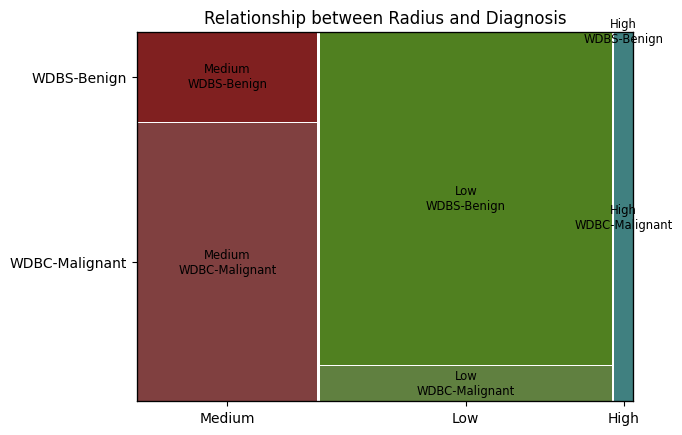

In [37]:
from statsmodels.graphics.mosaicplot import mosaic

# Convert a quantitative variable into categories
cancer['radius_category'] = pd.cut(
    cancer['mean radius'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

# Mosaic plot
plt.figure(figsize=(8, 6))

mosaic(
    cancer,
    ['radius_category', 'target'],
    title='Relationship between Radius and Diagnosis'
)

plt.show()

# Probability

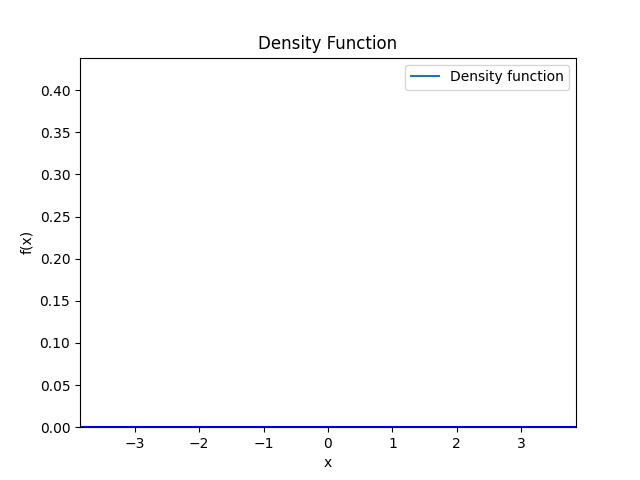

In [176]:
fig, ax = plt.subplots()

# 1. Defining the data
x = np.linspace(-3.5, 3.5, 200)
y = scipy.stats.norm.pdf(x)


# 2. Static aspects of the plot
ax.axhline(0, color='blue')

ax.set_ylim(0, np.max(y) * 1.1)
ax.set_xlim(np.min(x) * 1.1, np.max(x) * 1.1)
ax.set_title('Density Function')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')

# 3. Dynamic components
p_line, = ax.plot(
    [],
    [],
    label='Density function'
)

ax.legend()


# 4. Defining the update function
def update(frame):

    x_coords = x[:frame + 1]
    y_coords = y[:frame + 1]

    p_line.set_data(
        x_coords,
        y_coords
    )

    return p_line,


# 5. Creating the animation
animation = FuncAnimation(
    fig=fig,
    func=update,
    frames=len(x),
    interval=30,
    blit=True,
    repeat=True
)


# 6. Exporting the figure
animation.save(
    filename='Density plot.gif',
    writer='pillow',
    fps=30
)

plt.close()

# 7. Displaying the figure
display(Image(filename='Density plot.gif'))

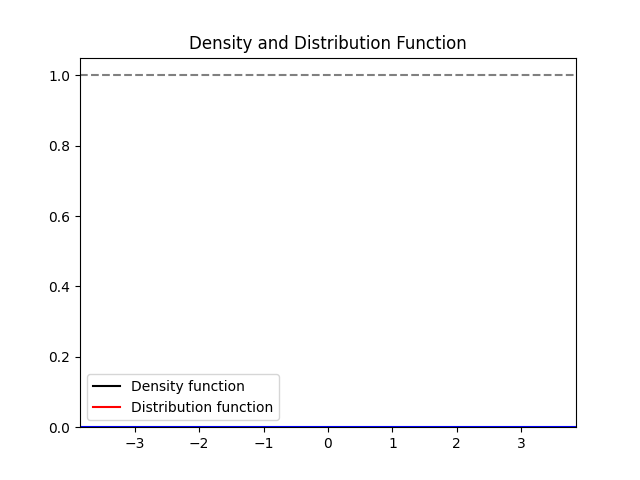

In [177]:
fig, ax = plt.subplots()

# 1. Defining the data
x = np.linspace(-3.5, 3.5, 200)
pdf = scipy.stats.norm.pdf(x)
cdf = scipy.stats.norm.cdf(x)


# 2. Static aspects of the plot
ax.axhline(0, color='blue')
ax.set_ylim(0, 1.05)
ax.set_xlim(np.min(x) * 1.1, np.max(x) * 1.1)
ax.axhline(1, color='grey', linestyle='--')
ax.set_title('Density and Distribution Function')


# 3. Dynamic components
pdf_line, = ax.plot([], [], label='Density function', color='black');
cdf_line, = ax.plot([], [], label='Distribution function', color='red');
ax.legend()

# 4. Defining the update function
def update(frame):

  x_coords = x[:frame]
  pdf_coords = pdf[:frame]
  cdf_coords = cdf[:frame]

  pdf_line.set_data(x_coords, pdf_coords)
  cdf_line.set_data(x_coords, cdf_coords)

  return pdf_line, cdf_line,

# 5. Creating the animation
animation = FuncAnimation(
    fig = fig,
    func = update,
    frames = len(x),
    interval = 1,
    blit = True,
    repeat = True
)

# 6. Exporting the figure
animation.save(filename='Density and distribution.gif',
               writer='pillow',
               fps=40)

plt.close(fig)


# 7. Displaying the figure
display(Image(filename='Density and distribution.gif'))

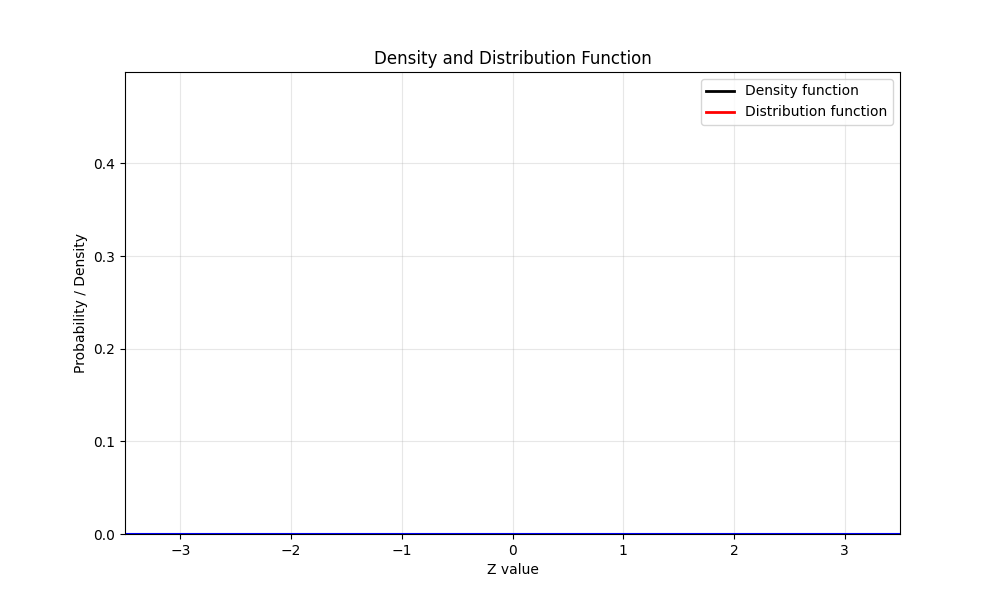

In [178]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt

from matplotlib.animation import FuncAnimation
from IPython.display import Image, display


fig, ax = plt.subplots(figsize=(10, 6))


# 1. Defining the data

x = np.linspace(-3.5, 3.5, 200)

pdf = scipy.stats.norm.pdf(x)
cdf = scipy.stats.norm.cdf(x)


# 2. Static aspects of the plot

ax.axhline(0, color='blue')

ax.set_xlim(np.min(x), np.max(x))

ax.set_ylim(0, np.max(pdf) * 1.25)

ax.set_xlabel('Z value')

ax.set_ylabel('Probability / Density')

ax.set_title('Density and Distribution Function')

ax.grid(alpha=0.3)


# 3. Dynamic components

pdf_line, = ax.plot(
    [], [],
    label='Density function',
    color='black',
    linewidth=2
)

cdf_line, = ax.plot(
    [], [],
    label='Distribution function',
    color='red',
    linewidth=2
)

ax.legend()


# 4. Defining the update function

def update(frame):

    x_coords = x[:frame]
    pdf_coords = pdf[:frame]
    cdf_coords = cdf[:frame]

    pdf_line.set_data(
        x_coords,
        pdf_coords
    )

    cdf_line.set_data(
        x_coords,
        cdf_coords
    )

    return pdf_line, cdf_line


# 5. Creating the animation

animation = FuncAnimation(
    fig=fig,
    func=update,
    frames=len(x),
    interval=30,
    blit=True,
    repeat=True
)


# 6. Exporting the figure

animation.save(
    filename='Density and distribution.gif',
    writer='pillow',
    fps=40
)

plt.close(fig)


# 7. Displaying the figure

display(
    Image(
        filename='Density and distribution.gif'
    )
)